# NER Evaluation: Model Comparison

This notebook analyses the NER evaluation scores across different models,
showing only **relaxed** precision/recall/F1 metrics and filtering out runs
with API/parsing failures (`count_failed_pages > 0`), so that only correct F1 scores are shown.

---
**How to use:**
1. Set `PROMPT_LANGUAGE`, `PROMPT_MODE` and `TEMPERATURE` in the configuration
   cell below to match the evaluation data you want to analyse.

**Configuration options:**
- `PROMPT_LANGUAGE`: `"dutch"` or `"english"`
- `PROMPT_MODE`: `"zeroshot"` or `"fewshot"`
- `TEMPERATURE`: `0.0` (float — must match the value in scores.csv)

The notebook filters the `scores.csv` to only include rows matching all three
settings. If you change the config, re-run all cells to update the figures.

In [ ]:
# ============================================================
# CONFIGURATION — change these to match your evaluation run
# ============================================================
PROMPT_LANGUAGE = "dutch"   # "dutch" or "english"
PROMPT_MODE = "fewshot"    # "zeroshot" or "fewshot"
TEMPERATURE = 1.0           # float — must match scores.csv (0 | 0.5 | 1.0)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

CONFIG_LABEL = f"{PROMPT_LANGUAGE} / {PROMPT_MODE} / t={TEMPERATURE}"
print(f"Configuration: {CONFIG_LABEL}")
print("Imports loaded")

Configuration: dutch / zeroshot / t=0.0
Imports loaded


## Progress Tracker for Configurations

Checks which model × configuration combinations have been completed by
scanning for the existence of output `.spacy` files. ✅ = run completed,
❌ = still to do.

**Models:** the 8 models used in this study.
**Configurations:** language (dutch/english) × mode (zeroshot/fewshot) ×
temperature (0.0 / 0.5 / 1.0).

In [24]:
# --- Run Tracker ---
# Scans ner-output/ for completed .spacy files and shows a completion matrix.

NER_OUTPUT = Path.cwd().parent / "ner" / "ner-output"
if not NER_OUTPUT.exists():
    NER_OUTPUT = Path.cwd() / "ner-output"

# The 8 models used in this study
MODELS = [
    "gemma4:31b",
    "deepseek-v4-pro",
    "deepseek-v4-flash",
    "mistral-large-3:675b",
    "qwen3.5:397b",
    "kimi-k2.7-code",
    "cogito-2.1:671b",
    "glm-5.1",
]

# Configurations to track
LANGUAGES = ["dutch", "english"]
MODES = ["zeroshot", "fewshot"]
TEMPERATURES = [0.0, 0.5, 1.0]

LETTER = "1816_third_letter"
SHORT = "1816"

# Build completion matrix
rows = []
for model in MODELS:
    row = {"Model": model}
    for lang in LANGUAGES:
        for mode in MODES:
            for temp in TEMPERATURES:
                spacy_path = (
                    NER_OUTPUT / model / SHORT /
                    f"{LETTER}__{model}_t{temp}_{mode}_{lang}.spacy"
                )
                col = f"{lang[:3]}/{mode[:3]}/t={temp}"
                row[col] = "✅" if spacy_path.exists() else "❌"
    rows.append(row)

tracker = pd.DataFrame(rows).set_index("Model")

# Count completed per model
tracker["✅ Completed"] = (tracker.values == "✅").sum(axis=1)
tracker["❌ Remaining"] = (tracker.values == "❌").sum(axis=1)

print(f"Scanning: {NER_OUTPUT}")
print(f"Total combos: {len(MODELS)} models × {len(LANGUAGES)} langs × {len(MODES)} modes × {len(TEMPERATURES)} temps = {len(MODELS) * len(LANGUAGES) * len(MODES) * len(TEMPERATURES)}\n")
tracker

Scanning: /home/tijn-do/hist-dutch-travelogues-nlp/ner/ner-output
Total combos: 8 models × 2 langs × 2 modes × 3 temps = 96



,dut/zer/t=0.0,dut/zer/t=0.5,dut/zer/t=1.0,dut/few/t=0.0,dut/few/t=0.5,dut/few/t=1.0,eng/zer/t=0.0,eng/zer/t=0.5,eng/zer/t=1.0,eng/few/t=0.0,eng/few/t=0.5,eng/few/t=1.0,✅ Completed,❌ Remaining
Model,,,,,,,,,,,,,,
gemma4:31b,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,12,0
deepseek-v4-pro,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,12,0
deepseek-v4-flash,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,12,0
mistral-large-3:675b,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,12,0
qwen3.5:397b,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,12,0
kimi-k2.7-code,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,12,0
cogito-2.1:671b,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,12,0
glm-5.1,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,12,0


## Top 10 Overall Relaxed F1 Across All Configurations

Horizontal bar chart showing the 10 best overall relaxed F1 scores across
all models, languages, prompting modes, and temperatures.

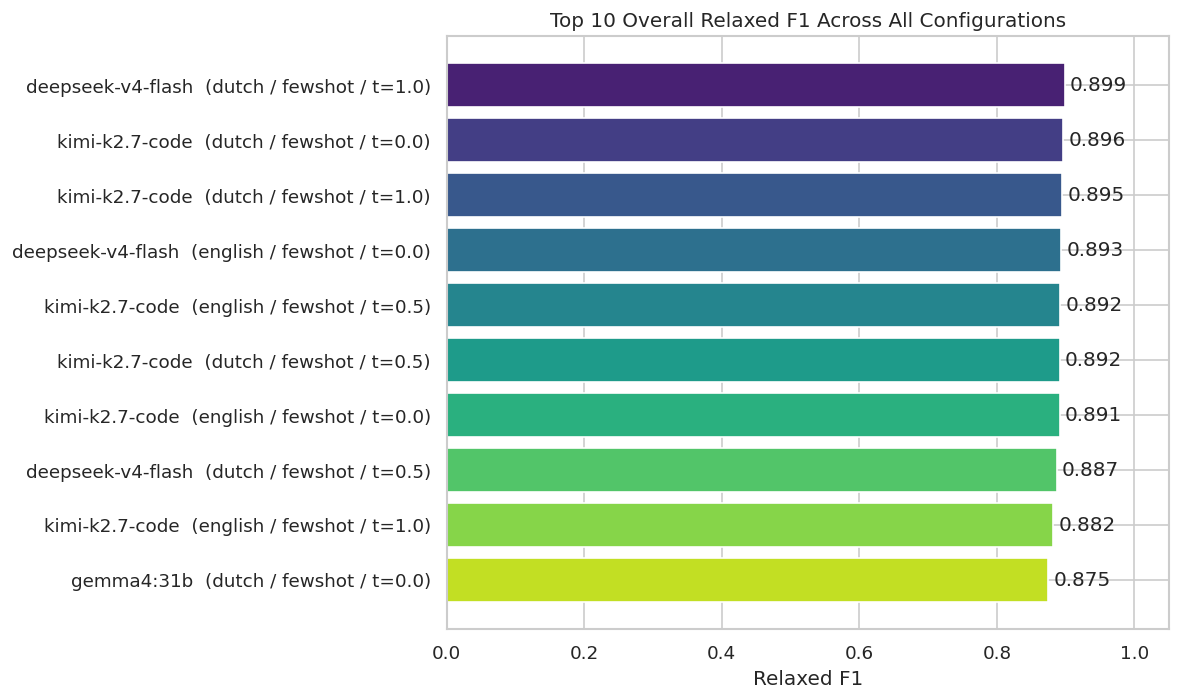


Full ranking of all model × configuration combinations:


,model,config,relaxed_p,relaxed_r,relaxed_f1
0,deepseek-v4-flash,dutch / fewshot / t=1.0,0.9118,0.8857,0.8986
1,kimi-k2.7-code,dutch / fewshot / t=0.0,0.8735,0.9206,0.8964
2,kimi-k2.7-code,dutch / fewshot / t=1.0,0.8827,0.9079,0.8951
3,deepseek-v4-flash,english / fewshot / t=0.0,0.9082,0.8794,0.8935
4,kimi-k2.7-code,english / fewshot / t=0.5,0.8921,0.8921,0.8921
...,...,...,...,...,...
91,cogito-2.1:671b,dutch / zeroshot / t=0.0,0.7220,0.5524,0.6259
92,cogito-2.1:671b,english / zeroshot / t=1.0,0.7960,0.5079,0.6202
93,cogito-2.1:671b,english / zeroshot / t=0.5,0.7111,0.5079,0.5926
94,cogito-2.1:671b,dutch / zeroshot / t=1.0,0.7308,0.4825,0.5813


In [25]:
# --- Top 10 Overall Relaxed F1 Across All Configurations ---
# Load fresh, filter failed pages, deduplicate, keep all configs
SCORES_PATH = Path.cwd().parent / "ner" / "ner-evaluation" / "scores.csv"
if not SCORES_PATH.exists():
    SCORES_PATH = Path.cwd() / "ner-evaluation" / "scores.csv"

df_top10 = pd.read_csv(SCORES_PATH)
df_top10 = df_top10[df_top10["count_failed_pages"] == 0].copy()
df_top10["datetime"] = pd.to_datetime(df_top10["datetime"])
df_top10 = df_top10.sort_values("datetime").groupby(
    ["model", "label", "prompt_language", "prompting_method", "temperature"],
    dropna=False
).last().reset_index()

# Only OVERALL rows, build a readable config label
overall_top10 = df_top10[df_top10["label"] == "OVERALL"].copy()
overall_top10["config"] = overall_top10.apply(
    lambda r: f"{r['prompt_language']} / {r['prompting_method']} / t={r['temperature']}", axis=1
)

# Build a combined label for the y-axis: model + config
overall_top10["label_display"] = overall_top10.apply(
    lambda r: f"{r['model']}  ({r['config']})", axis=1
)

# Sort by relaxed_f1 descending, take top 10
top10 = overall_top10.sort_values("relaxed_f1", ascending=False).head(10)

# Plot: horizontal bar chart, best at top
fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("viridis", len(top10))
bars = ax.barh(
    top10["label_display"][::-1],   # reverse so best is at top
    top10["relaxed_f1"][::-1],
    color=colors[::-1],
    edgecolor="white",
)
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_xlabel("Relaxed F1")
ax.set_title("Top 10 Overall Relaxed F1 Across All Configurations")
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.show()

# Also print the full ranking table
print("\nFull ranking of all model × configuration combinations:")
ranking = overall_top10.sort_values("relaxed_f1", ascending=False).reset_index(drop=True)
ranking[["model", "config", "relaxed_p", "relaxed_r", "relaxed_f1"]]

## Gold Standard Entity Counts

Number of annotated entities per label in the 1816 ground truth (Recogito JSON-LD).

In [ ]:
# --- Gold Standard Entity Counts ---
# Load the Recogito JSON-LD and count entities per CIDOC-CRM label

GS_PATH = Path.cwd().parent / "ner" / "gs_annotations" / "1816.jsonld"
if not GS_PATH.exists():
    GS_PATH = Path.cwd() / "gs_annotations" / "1816.jsonld"

import json
from collections import Counter

gs_data = json.loads(GS_PATH.read_text())

label_counts = Counter()
for ann in gs_data:
    for body in ann.get("body", []):
        if body.get("purpose") == "tagging":
            # Normalise to NER label format: "E53 Place" → "E53_Place", "E52 Time-Span" → "E52_Time_Span"
            raw = body.get("value", "unknown")
            normalised = raw.replace(" ", "_").replace("-", "_")
            label_counts[normalised] += 1

# Build a DataFrame in the same order as the NER label_order
label_order = [
    "E53_Place", "E18_Physical_Thing", "E19_Physical_Object",
    "Mode_of_Transportation", "E52_Time_Span", "E20_Biological_Object",
    "F2_Expression", "E31_Document",
]
gs_df = pd.DataFrame([
    {"Label": lbl, "Count": label_counts.get(lbl, 0)}
    for lbl in label_order
])
gs_df["%"] = (gs_df["Count"] / gs_df["Count"].sum() * 100).round(1)

print(f"Total annotations: {len(gs_data)}")
print(f"Total tagged entities: {gs_df['Count'].sum()}\n")
gs_df.style.format({"Count": "{:d}", "%": "{:.1f}%"})

## 1. Load and filter data

- Exclude runs where `count_failed_pages > 0` (API errors, parsing failures)
- Keep only rows matching the configured `PROMPT_LANGUAGE` and `PROMPT_MODE`
- For models with multiple valid runs, keep only the most recent one

In [26]:
SCORES_PATH = Path.cwd().parent / "ner" / "ner-evaluation" / "scores.csv"
if not SCORES_PATH.exists():
    SCORES_PATH = Path.cwd() / "ner-evaluation" / "scores.csv"

df = pd.read_csv(SCORES_PATH)
print(f"Loaded {len(df)} rows from {SCORES_PATH.name}")
print(f"Columns: {list(df.columns)}")

Loaded 945 rows from scores.csv
Columns: ['source_text', 'model', 'temperature', 'prompting_method', 'prompt_language', 'pages_processed', 'duration_seconds', 'inference_type', 'count_failed_pages', 'datetime', 'label', 'strict_p', 'strict_r', 'strict_f1', 'relaxed_p', 'relaxed_r', 'relaxed_f1', 'count_tp', 'count_fp', 'count_fn']


In [27]:
# --- Filter by configured language, mode and temperature ---
n_before = len(df)
df = df[
    (df["prompt_language"] == PROMPT_LANGUAGE) &
    (df["prompting_method"] == PROMPT_MODE) &
    (df["temperature"] == TEMPERATURE)
].copy()
print(f"Filtered to {CONFIG_LABEL}: {len(df)} rows "
      f"({n_before - len(df)} rows removed)")

# --- Filter out runs with failed pages ---
n_before = len(df)
df = df[df["count_failed_pages"] == 0].copy()
n_removed = n_before - len(df)
print(f"Removed {n_removed} rows with count_failed_pages > 0")
print(f"Remaining: {len(df)} rows")

# --- For models with multiple valid runs, keep the most recent ---
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").groupby(
    ["model", "label"],
    dropna=False
).last().reset_index()
print(f"After deduplication: {len(df)} rows")

# --- Summary of included runs ---
summary = df[df["label"] == "OVERALL"][[
    "model", "prompting_method", "prompt_language", "temperature",
    "duration_seconds", "datetime", "count_failed_pages"
]].sort_values("model").reset_index(drop=True)
summary

Filtered to dutch / zeroshot / t=0.0: 72 rows (873 rows removed)
Removed 0 rows with count_failed_pages > 0
Remaining: 72 rows
After deduplication: 72 rows


,model,prompting_method,prompt_language,temperature,duration_seconds,datetime,count_failed_pages
0,cogito-2.1:671b,zeroshot,dutch,0.0,94.6,2026-06-15 16:53:52,0
1,deepseek-v4-flash,zeroshot,dutch,0.0,783.2,2026-06-15 16:54:15,0
2,deepseek-v4-pro,zeroshot,dutch,0.0,861.4,2026-06-15 16:54:37,0
3,gemma4:31b,zeroshot,dutch,0.0,133.4,2026-06-15 16:54:59,0
4,glm-5.1,zeroshot,dutch,0.0,2522.2,2026-06-15 16:55:22,0
5,kimi-k2.7-code,zeroshot,dutch,0.0,1474.0,2026-06-15 16:55:44,0
6,mistral-large-3:675b,zeroshot,dutch,0.0,223.4,2026-06-15 16:56:08,0
7,qwen3.5:397b,zeroshot,dutch,0.0,1669.0,2026-06-15 16:56:31,0


## 2. Overall Relaxed F1 by Model

Horizontal bar chart showing each model's overall relaxed F1 score.

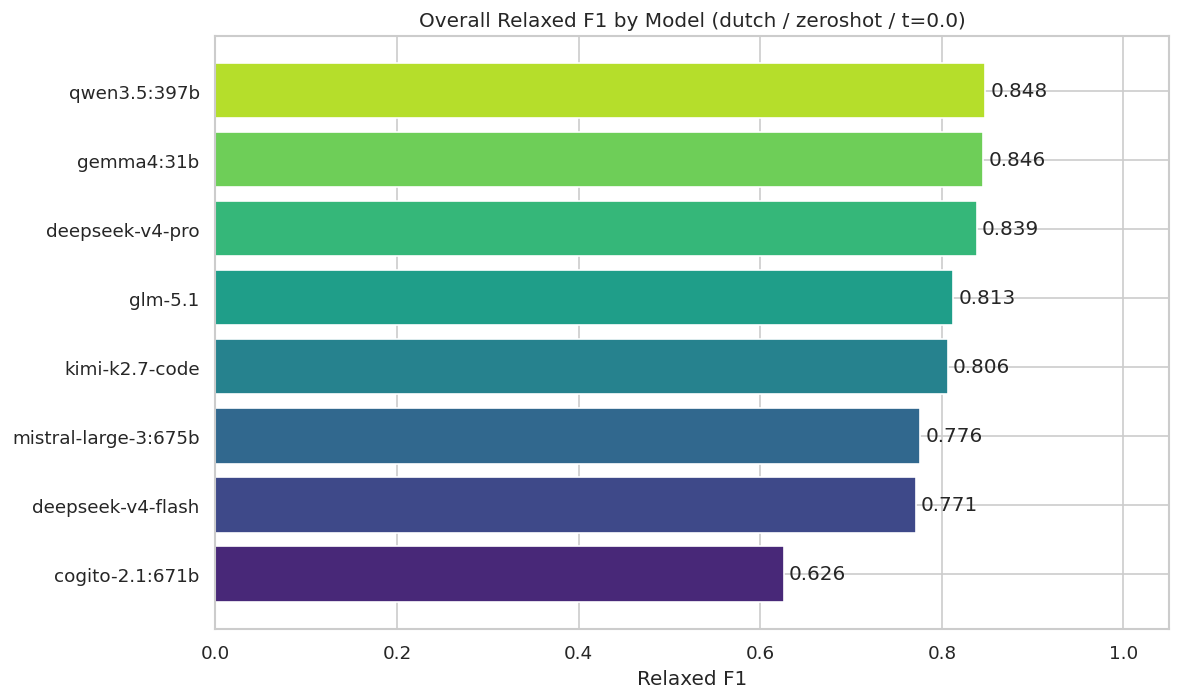

In [28]:
overall = df[df["label"] == "OVERALL"].copy().sort_values("relaxed_f1")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    overall["model"],
    overall["relaxed_f1"],
    color=sns.color_palette("viridis", len(overall)),
    edgecolor="white",
)
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_xlabel("Relaxed F1")
ax.set_title(f"Overall Relaxed F1 by Model ({CONFIG_LABEL})")
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.show()

## 3. Per-Label F1 Heatmap

Models as rows, entity labels as columns, colour = relaxed F1.

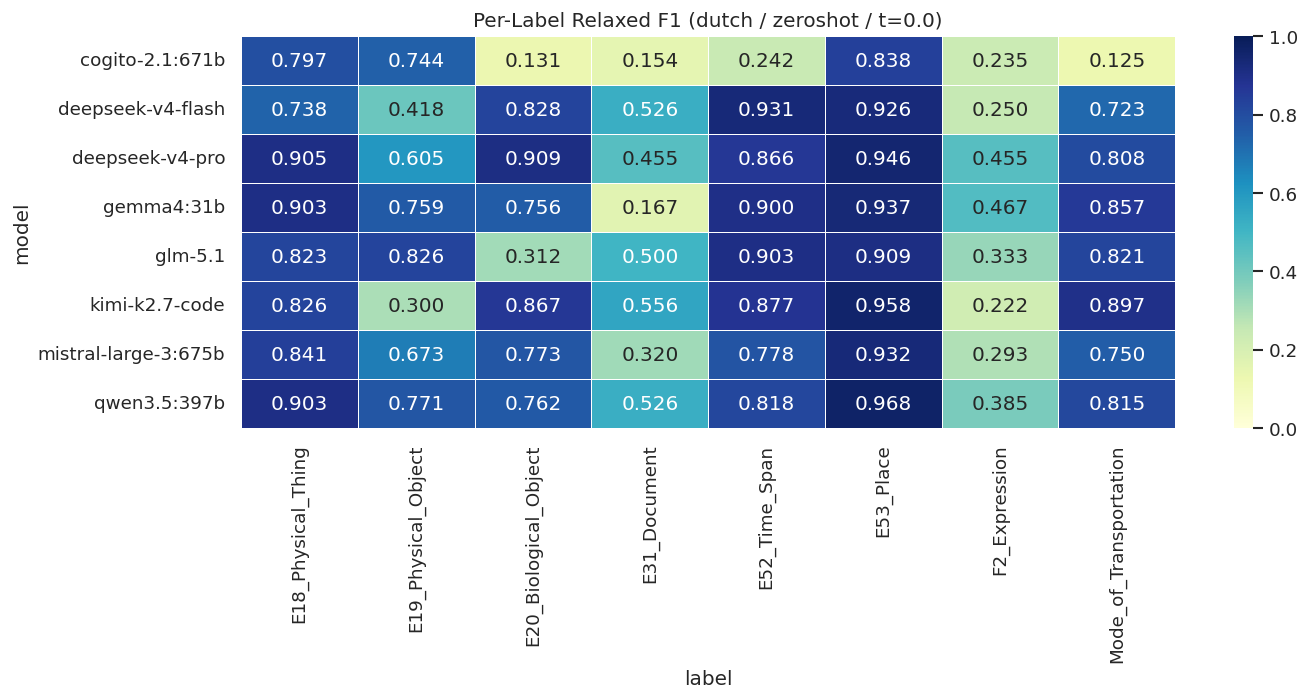

In [29]:
per_label = df[df["label"] != "OVERALL"].copy()
pivot = per_label.pivot_table(
    index="model",
    columns="label",
    values="relaxed_f1",
    aggfunc="last",
)
# Order columns: E labels first, then F2, then Mode_of_Transportation
label_order = [
    "E18_Physical_Thing", "E19_Physical_Object", "E20_Biological_Object",
    "E31_Document", "E52_Time_Span", "E53_Place",
    "F2_Expression", "Mode_of_Transportation",
]
pivot = pivot[[c for c in label_order if c in pivot.columns]]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu",
            vmin=0, vmax=1, linewidths=0.5, ax=ax)
ax.set_title(f"Per-Label Relaxed F1 ({CONFIG_LABEL})")
plt.tight_layout()
plt.show()

## 4. Per-Label Relaxed Precision & Recall

One subplot per entity label, showing precision and recall side by side.

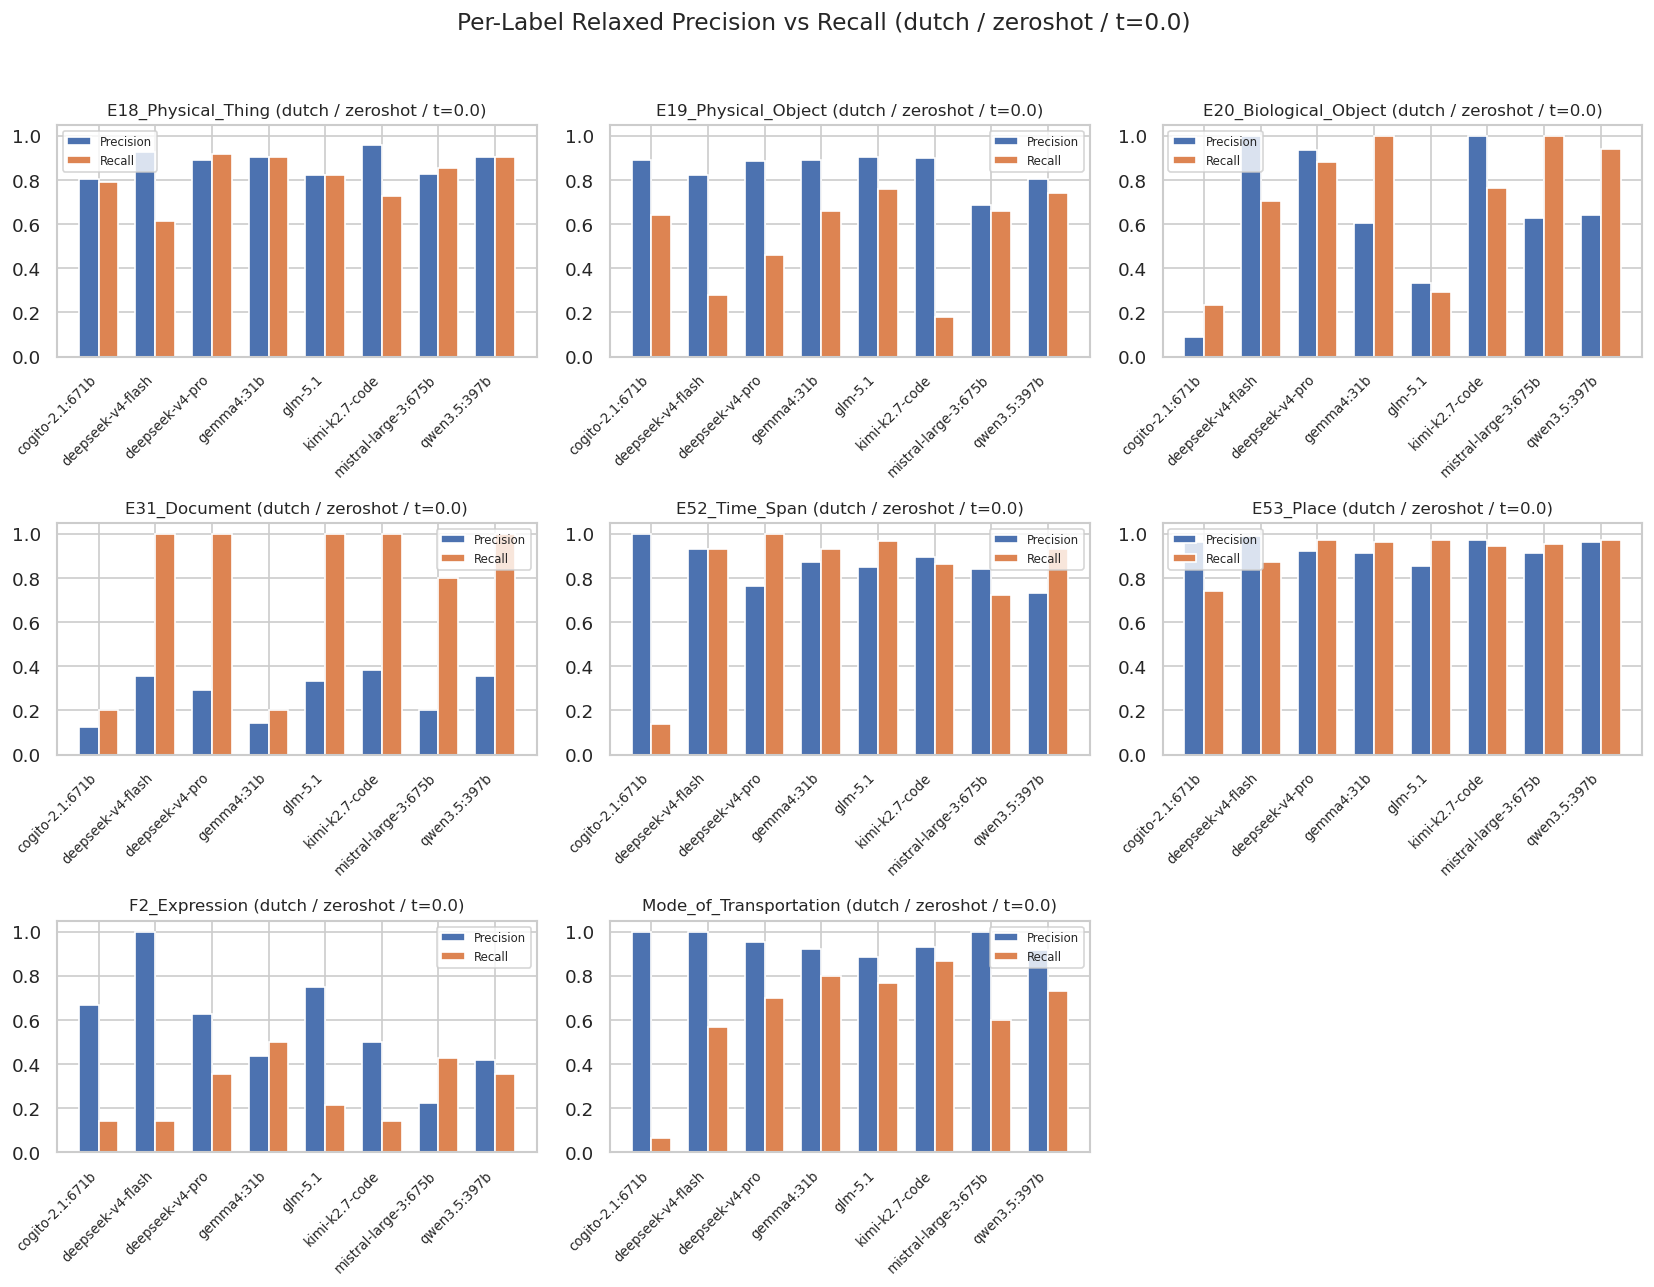

In [30]:
labels = [c for c in label_order if c in per_label["label"].unique()]
n_labels = len(labels)
n_cols = 3
n_rows = int(np.ceil(n_labels / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows))
axes = axes.flatten()

for i, lbl in enumerate(labels):
    ax = axes[i]
    subset = per_label[per_label["label"] == lbl].sort_values("model")
    x = np.arange(len(subset))
    width = 0.35
    ax.bar(x - width/2, subset["relaxed_p"], width, label="Precision", color="#4C72B0")
    ax.bar(x + width/2, subset["relaxed_r"], width, label="Recall", color="#DD8452")
    ax.set_xticks(x)
    ax.set_xticklabels(subset["model"], rotation=45, ha="right", fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{lbl} ({CONFIG_LABEL})", fontsize=10)
    ax.legend(fontsize=7)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f"Per-Label Relaxed Precision vs Recall ({CONFIG_LABEL})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5a. Inference Time Comparison

How long each model took to process all pages.

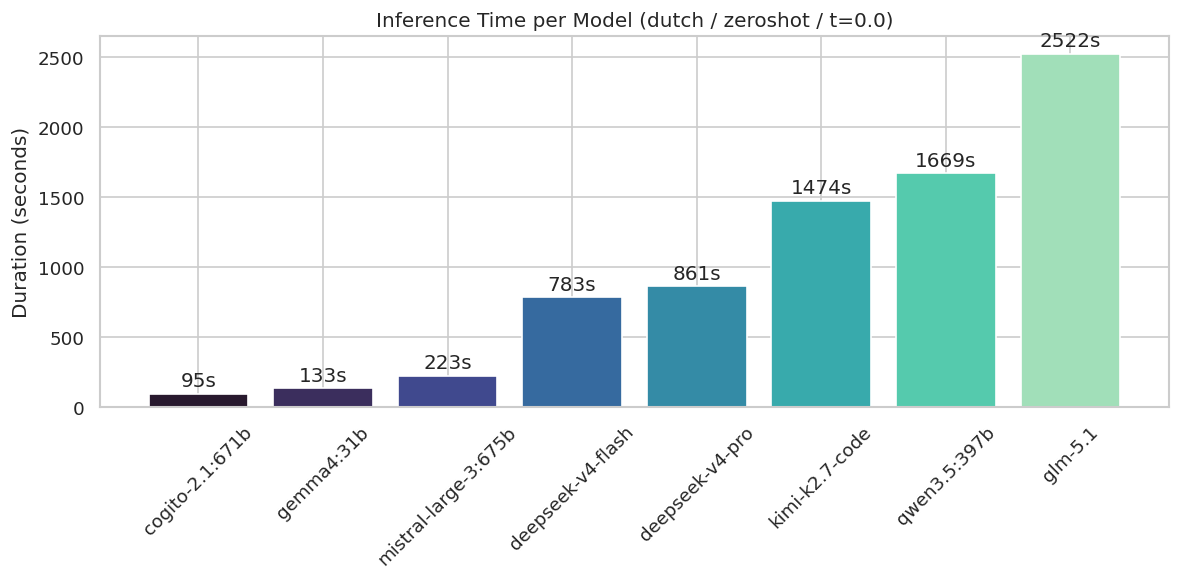

In [31]:
timing = overall.sort_values("duration_seconds")

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    timing["model"],
    timing["duration_seconds"],
    color=sns.color_palette("mako", len(timing)),
    edgecolor="white",
)
ax.bar_label(bars, fmt="%.0fs", padding=2)
ax.set_ylabel("Duration (seconds)")
ax.set_title(f"Inference Time per Model ({CONFIG_LABEL})")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 5b. Inference Time vs Relaxed F1

Scatter plot showing the trade-off between inference speed and performance.
Models in the top-left quadrant are both fast and accurate.

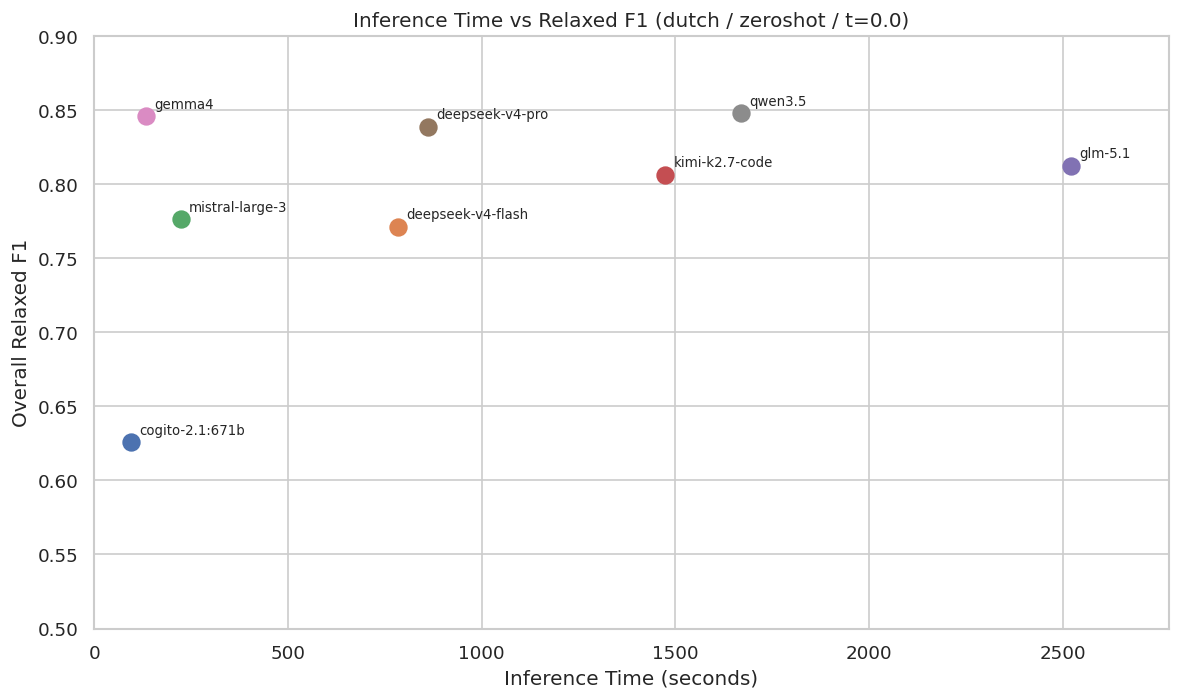

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter: time vs F1, labelled by model
for _, row in overall.iterrows():
    ax.scatter(row["duration_seconds"], row["relaxed_f1"], s=100, zorder=5)
    ax.annotate(
        row["model"].replace(":31b", "").replace(":397b", "").replace(":675b", ""),
        (row["duration_seconds"], row["relaxed_f1"]),
        xytext=(5, 5), textcoords="offset points", fontsize=8,
    )

ax.set_xlabel("Inference Time (seconds)")
ax.set_ylabel("Overall Relaxed F1")
ax.set_title(f"Inference Time vs Relaxed F1 ({CONFIG_LABEL})")
ax.set_xlim(0, overall["duration_seconds"].max() * 1.1)
ax.set_ylim(0.5, 0.9)
plt.tight_layout()
plt.show()

## 5c. Expected Inference Time for the Full Transcription of 1816

Expected inference time for the full ~240-page 1816 transcription, based on the
**average inference time across all completed configurations** (all languages ×
modes × temperatures) per model on the 10-page test set.

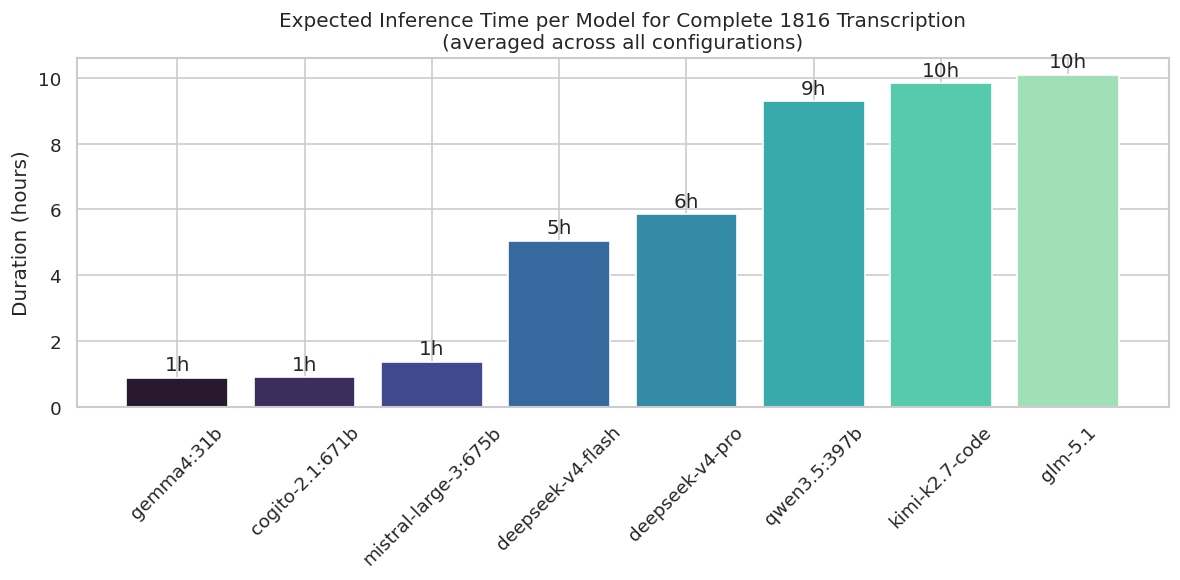

Average inference time per model (10 pages):


,model,duration_seconds
3,gemma4:31b,147.30s
0,cogito-2.1:671b,148.24s
6,mistral-large-3:675b,227.62s
1,deepseek-v4-flash,837.77s
2,deepseek-v4-pro,970.28s
7,qwen3.5:397b,1540.30s
5,kimi-k2.7-code,1631.68s
4,glm-5.1,1674.87s


In [33]:
# --- Load all runs, average inference time per model across all configs ---
df_all = pd.read_csv(SCORES_PATH)
df_all = df_all[df_all["count_failed_pages"] == 0].copy()
df_all["datetime"] = pd.to_datetime(df_all["datetime"])
df_all = df_all.sort_values("datetime").groupby(
    ["model", "label", "prompt_language", "prompting_method", "temperature"],
    dropna=False
).last().reset_index()

# Only OVERALL rows, group by model and average duration
overall_all = df_all[df_all["label"] == "OVERALL"].copy()
avg_duration = (
    overall_all.groupby("model")["duration_seconds"]
    .mean()
    .reset_index()
    .sort_values("duration_seconds")
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    avg_duration["model"],
    avg_duration["duration_seconds"] / 60 / 10 / 60 * 217,  # seconds → min → ÷10 pages → hours × 217 pages
    color=sns.color_palette("mako", len(avg_duration)),
    edgecolor="white",
)
ax.bar_label(bars, fmt="%.0fh", padding=2)
ax.set_ylabel("Duration (hours)")
ax.set_title("Expected Inference Time per Model for Complete 1816 Transcription\n(averaged across all configurations)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# Show the per-model averages used
print("Average inference time per model (10 pages):")
avg_duration.style.format({"duration_seconds": "{:.2f}s"})

## 6. Summary Table (Colour-Coded)

Pivot table with relaxed F1 per model per label, colour-coded for quick scanning.

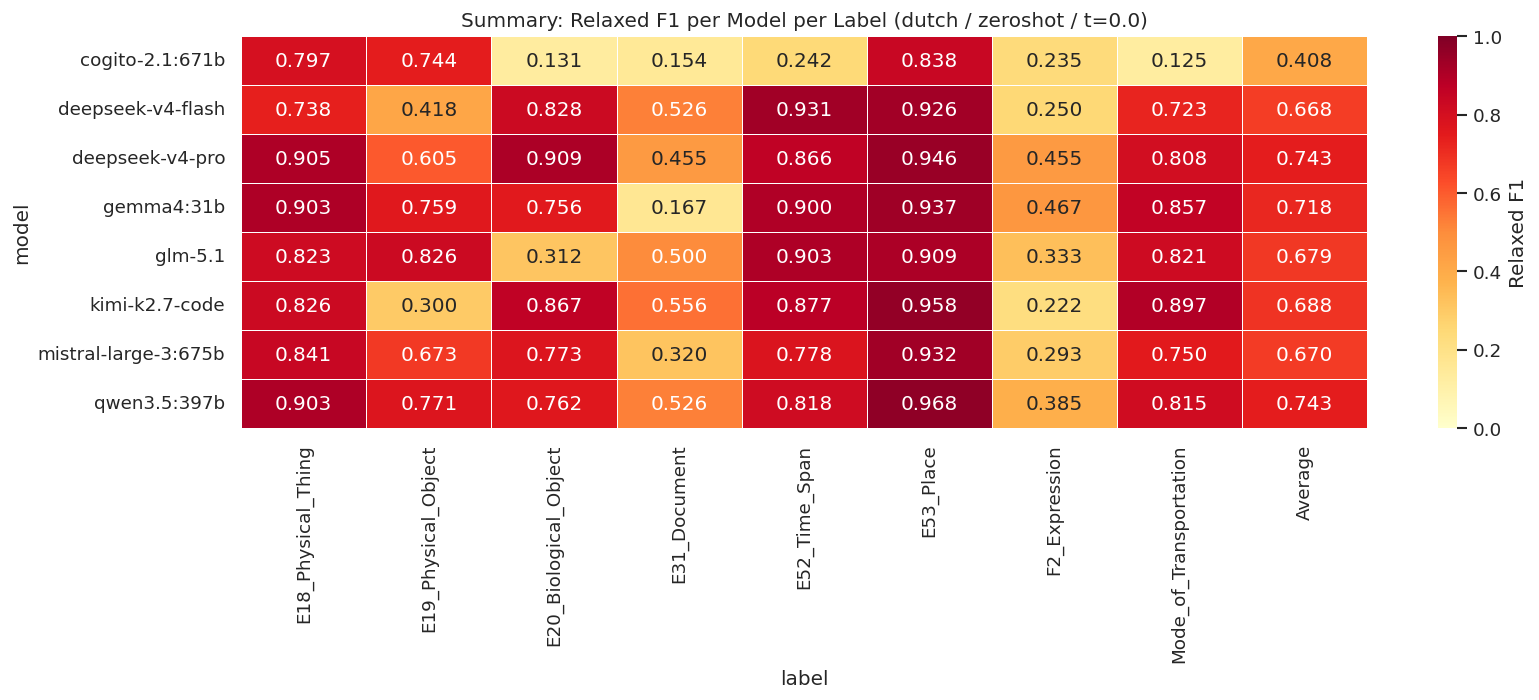

In [34]:
# Add an "Average" column
pivot["Average"] = pivot.mean(axis=1)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlOrRd",
            vmin=0, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={"label": "Relaxed F1"})
ax.set_title(f"Summary: Relaxed F1 per Model per Label ({CONFIG_LABEL})", fontsize=12)
plt.tight_layout()
plt.show()

## 7. Best Model per Label

Quick table showing which model achieves the highest relaxed F1 for each entity label.

In [35]:
best = per_label.loc[
    per_label.groupby("label")["relaxed_f1"].idxmax(),
    ["label", "model", "relaxed_p", "relaxed_r", "relaxed_f1"]
].set_index("label").sort_index()
best.columns = ["Best Model", "Precision", "Recall", "F1"]
best

,Best Model,Precision,Recall,F1
label,,,,
E18_Physical_Thing,deepseek-v4-pro,0.8906,0.9194,0.9048
E19_Physical_Object,glm-5.1,0.9048,0.7600,0.8261
E20_Biological_Object,deepseek-v4-pro,0.9375,0.8824,0.9091
E31_Document,kimi-k2.7-code,0.3846,1.0000,0.5556
E52_Time_Span,deepseek-v4-flash,0.9310,0.9310,0.9310
E53_Place,qwen3.5:397b,0.9633,0.9722,0.9677
F2_Expression,gemma4:31b,0.4375,0.5000,0.4667
Mode_of_Transportation,kimi-k2.7-code,0.9286,0.8667,0.8966


## 8. Overall F1 per Configuration

Heatmap showing each model's **overall relaxed F1** across all available
configurations (language × prompting mode × temperature). Models as rows,
configurations as columns, which makes it easy to spot which settings work best
for each model.

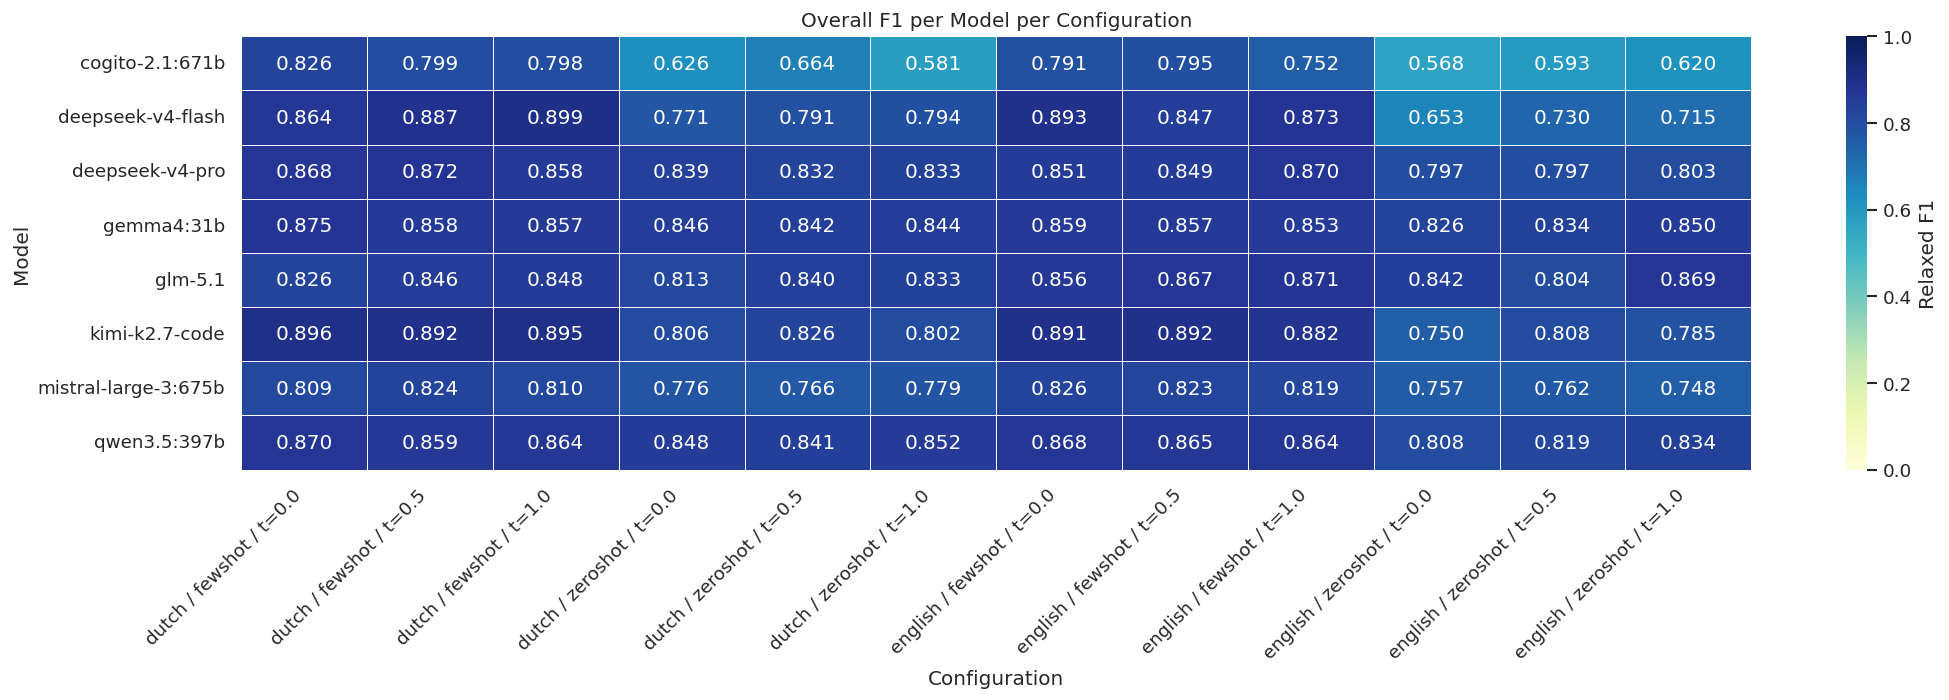

Configs shown: 12, Models: 8


In [36]:
# --- Overall F1 across all configs ---
# Load fresh, filter failed pages + deduplicate, keep all configs
df_full = pd.read_csv(SCORES_PATH)
df_full = df_full[df_full["count_failed_pages"] == 0].copy()
df_full["datetime"] = pd.to_datetime(df_full["datetime"])
df_full = df_full.sort_values("datetime").groupby(
    ["model", "label", "prompt_language", "prompting_method", "temperature"],
    dropna=False
).last().reset_index()

# Only OVERALL rows, build config label
overall_full = df_full[df_full["label"] == "OVERALL"].copy()
overall_full["config"] = overall_full.apply(
    lambda r: f"{r['prompt_language']} / {r['prompting_method']} / t={r['temperature']}", axis=1
)

# Pivot: models × configs, values = relaxed_f1
pivot_cfg = overall_full.pivot_table(
    index="model", columns="config", values="relaxed_f1", aggfunc="last",
)

# Sort config columns logically: language first, then mode, then temperature
col_order = sorted(pivot_cfg.columns)
pivot_cfg = pivot_cfg[col_order]

fig, ax = plt.subplots(figsize=(max(8, len(col_order) * 1.5), 6))
sns.heatmap(pivot_cfg, annot=True, fmt=".3f", cmap="YlGnBu",
            vmin=0, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={"label": "Relaxed F1"})
plt.xticks(rotation=45, ha='right')
ax.set_title("Overall F1 per Model per Configuration", fontsize=12)
ax.set_ylabel("Model")
ax.set_xlabel("Configuration")
plt.tight_layout()
plt.show()

print(f"Configs shown: {len(col_order)}, Models: {len(pivot_cfg)}")